# Attention-IQL vs IQL on Maze Offline RL

This notebook implements:

- IQL (paper implementation)
- Attention-IQL (Transformer-based)
- Heatmaps of value propagation
- Animated value propagation
- Trajectory stitching experiment
- Comparative plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Maze Environment

In [ ]:
class MazeEnv:
    def __init__(self):
        self.layout = [
            "#########",
            "#S      #",
            "# ### # #",
            "# #   # #",
            "# # ### #",
            "#   #   #",
            "# #######",
            "#G      #",
            "#########"
        ]
        self.height = len(self.layout)
        self.width = len(self.layout[0])
        self.start_pos = (1, 1) # Default, will be updated if 'S' is in layout
        self.goal_pos = (7, 1)  # Default, will be updated if 'G' is in layout
        self.cells = []

        for r in range(self.height):
            for c in range(self.width):
                if self.layout[r][c] == 'S':
                    self.start_pos = (r, c)
                elif self.layout[r][c] == 'G':
                    self.goal_pos = (r, c)
                if self.layout[r][c] != '#':
                    self.cells.append((r, c))

        self.state = self.start_pos
        self.actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    def reset(self):
        self.state = self.start_pos
        return np.array(self.state, dtype=np.float32)

    def step(self, action_idx):
        move = self.actions[action_idx]
        next_state = (self.state[0] + move[0], self.state[1] + move[1])
        done = False

        # Check for wall collisions or out of bounds
        if not (0 <= next_state[0] < self.height and
                0 <= next_state[1] < self.width and
                self.layout[next_state[0]][next_state[1]] != '#'):
            next_state = self.state  # Stay in the current state
            reward = 0
        elif next_state == self.goal_pos:
            reward = 100
            done = True
        else:
            reward = -1

        self.state = next_state
        return np.array(self.state, dtype=np.float32), reward, done, {}

New Maze Layout:
#########
#S      #
# ### # #
# #   # #
# # ### #
#   #   #
# #######
#G      #
#########


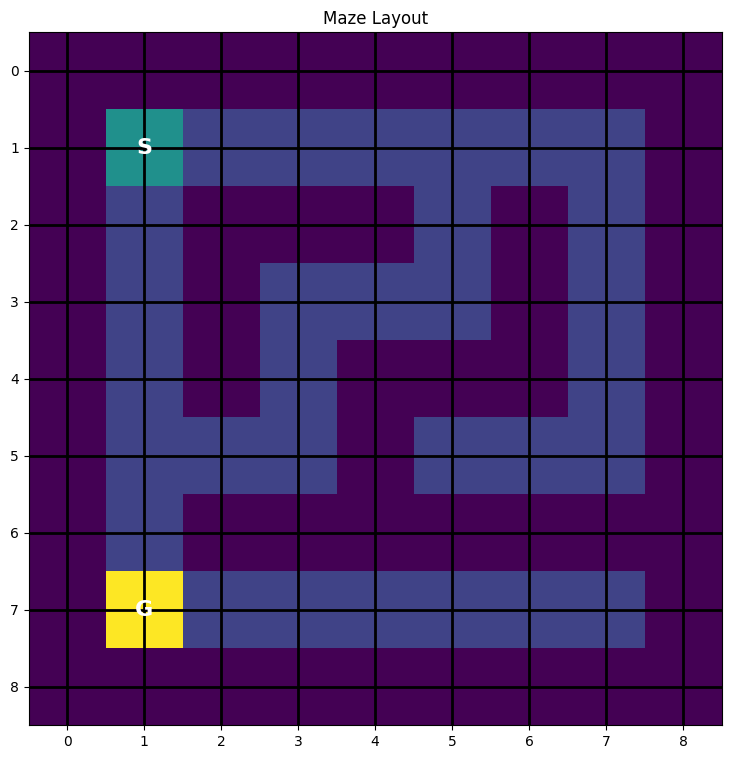

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maze(env):
    grid = np.zeros((env.height, env.width))
    for r in range(env.height):
        for c in range(env.width):
            if env.layout[r][c] == '#':
                grid[r, c] = 0 # Wall
            elif (r, c) == env.start_pos:
                grid[r, c] = 0.5 # Start
            elif (r, c) == env.goal_pos:
                grid[r, c] = 1.0 # Goal
            else:
                grid[r, c] = 0.2 # Path

    plt.figure(figsize=(env.width, env.height))
    plt.imshow(grid, cmap='viridis', origin='upper')
    plt.xticks(np.arange(env.width))
    plt.yticks(np.arange(env.height))
    plt.grid(True, color='black', linewidth=2)

    # Annotate S and G
    plt.text(env.start_pos[1], env.start_pos[0], 'S', ha='center', va='center', color='white', fontsize=16, fontweight='bold')
    plt.text(env.goal_pos[1], env.goal_pos[0], 'G', ha='center', va='center', color='white', fontsize=16, fontweight='bold')

    plt.title('Maze Layout')
    plt.show()

# Instantiate the environment and plot it
env = MazeEnv()
print("New Maze Layout:")
for row in env.layout:
    print(row)
plot_maze(env)

## Dataset Generation

In [ ]:
import collections
import numpy as np

def get_bfs_path(env, start, goal):
    # Ensure inputs are tuples of ints
    start = (int(start[0]), int(start[1]))
    goal = (int(goal[0]), int(goal[1]))
    queue = collections.deque([[start]])
    seen = {start}
    while queue:
        path = queue.popleft()
        curr = path[-1]
        if curr == goal: return path
        for action_idx, move in enumerate(env.actions):
            nxt = (int(curr[0] + move[0]), int(curr[1] + move[1]))
            if 0 <= nxt[0] < env.height and 0 <= nxt[1] < env.width and \
               env.layout[nxt[0]][nxt[1]] != '#' and nxt not in seen:
                queue.append(path + [nxt])
                seen.add(nxt)
    return None

def generate_dataset(env, n_expert=50, n_medium=100, n_random=50, max_traj_len=150):
    dataset = []
    env_inst = env

    # Generate Expert Trajectories
    expert_path = get_bfs_path(env_inst, env_inst.start_pos, env_inst.goal_pos)
    if expert_path:
        for _ in range(n_expert):
            for i in range(len(expert_path)-1):
                s = expert_path[i]
                next_s = expert_path[i+1]
                a = env_inst.actions.index((next_s[0]-s[0], next_s[1]-s[1]))
                dataset.append({'s': s, 'a': a, 'r': 100 if next_s == env_inst.goal_pos else -1, 's_next': next_s, 'd': next_s == env_inst.goal_pos})

    # Generate Random Trajectories
    for _ in range(n_random):
        s = env_inst.reset()
        for _ in range(max_traj_len):
            a = np.random.randint(4)
            s_next, r, d, _ = env_inst.step(a)
            dataset.append({'s': (int(s[0]), int(s[1])), 'a': a, 'r': r, 's_next': (int(s_next[0]), int(s_next[1])), 'd': d})
            s = s_next
            if d: break

    # Generate Medium Trajectories (mostly expert, some random)
    for _ in range(n_medium):
        s = env_inst.reset()
        for _ in range(max_traj_len):
            s_tuple = (int(s[0]), int(s[1]))
            if np.random.random() < 0.9: # Higher chance of following expert path
                path = get_bfs_path(env_inst, s_tuple, env_inst.goal_pos)
                if path and len(path) > 1:
                    next_s = path[1]
                    a = env_inst.actions.index((next_s[0]-s_tuple[0], next_s[1]-s_tuple[1]))
                else:
                    a = np.random.randint(4) # If no path or stuck, take random action
            else:
                a = np.random.randint(4)
            s_next, r, d, _ = env_inst.step(a)
            dataset.append({'s': s_tuple, 'a': a, 'r': r, 's_next': (int(s_next[0]), int(s_next[1])), 'd': d})
            s = s_next
            if d: break

    return dataset

env = MazeEnv()
offline_data = generate_dataset(env)
print(f"Dataset generated with {len(offline_data)} transitions.")

Dataset generated with 6121 transitions.


## IQL

In [ ]:

def expectile_loss(diff, tau=0.9):
    weight = torch.where(diff > 0, tau, 1 - tau)
    return (weight * diff.pow(2)).mean()


In [ ]:
def expectile_loss(diff, tau=0.7):
    weight = torch.where(diff > 0, tau, 1 - tau)
    return (weight * diff.pow(2)).mean()

class ValueNetwork(nn.Module):
    def __init__(self, state_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, s): return self.net(s)

class QNetwork(nn.Module):
    def __init__(self, state_dim=2, action_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim + action_dim, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, s, a):
        a_onehot = F.one_hot(a.long(), num_classes=4).float()
        return self.net(torch.cat([s, a_onehot], dim=-1))

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim=2, action_dim=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, 128), nn.ReLU(), nn.Linear(128, 128), nn.ReLU(), nn.Linear(128, action_dim))
    def forward(self, s): return self.net(s)

def train_iql(data, epochs=100, tau=0.7, gamma=0.99, beta=3.0):
    v_net, q_net, p_net = ValueNetwork().to(device), QNetwork().to(device), PolicyNetwork().to(device)
    v_opt = torch.optim.Adam(v_net.parameters(), lr=1e-3)
    q_opt = torch.optim.Adam(q_net.parameters(), lr=1e-3)
    p_opt = torch.optim.Adam(p_net.parameters(), lr=1e-3)

    s = torch.tensor([d['s'] for d in data], dtype=torch.float32).to(device)
    a = torch.tensor([d['a'] for d in data], dtype=torch.long).to(device)
    r = torch.tensor([d['r'] for d in data], dtype=torch.float32).to(device)
    s_next = torch.tensor([d['s_next'] for d in data], dtype=torch.float32).to(device)
    dones = torch.tensor([d['d'] for d in data], dtype=torch.float32).to(device)

    for epoch in range(epochs):
        with torch.no_grad(): target_q = q_net(s, a.float()).squeeze()
        v_val = v_net(s).squeeze()
        v_loss = expectile_loss(target_q - v_val, tau=tau)
        v_opt.zero_grad(); v_loss.backward(); v_opt.step()

        with torch.no_grad(): q_target_val = r + gamma * (1 - dones) * v_net(s_next).squeeze()
        q_loss = F.mse_loss(q_net(s, a.float()).squeeze(), q_target_val)
        q_opt.zero_grad(); q_loss.backward(); q_opt.step()

        with torch.no_grad():
            adv = q_net(s, a.float()).squeeze() - v_net(s).squeeze()
            exp_adv = torch.exp(beta * adv).clamp(max=100.0)
        logits = p_net(s)
        p_loss = (exp_adv * F.cross_entropy(logits, a, reduction='none')).mean()
        p_opt.zero_grad(); p_loss.backward(); p_opt.step()

        if (epoch + 1) % 10 == 0: print(f"IQL Epoch {epoch+1}, V Loss: {v_loss.item():.4f}, P Loss: {p_loss.item():.4f}")
    return v_net, q_net, p_net

iql_v, iql_q, iql_p = train_iql(offline_data)
print("IQL Training complete.")

IQL Epoch 10, V Loss: 0.0246, P Loss: 1.8489
IQL Epoch 20, V Loss: 0.0296, P Loss: 1.5718
IQL Epoch 30, V Loss: 0.0555, P Loss: 1.3471
IQL Epoch 40, V Loss: 0.1576, P Loss: 1.1234
IQL Epoch 50, V Loss: 0.5266, P Loss: 1.1848
IQL Epoch 60, V Loss: 1.2433, P Loss: 1.3397
IQL Epoch 70, V Loss: 2.5810, P Loss: 1.0110
IQL Epoch 80, V Loss: 5.0744, P Loss: 0.6888
IQL Epoch 90, V Loss: 9.5709, P Loss: 1.3965
IQL Epoch 100, V Loss: 17.1029, P Loss: 5.7958
IQL Training complete.


### Re-training IQL

In [ ]:
print("Re-training IQL...")
iql_v, iql_q, iql_p = train_iql(offline_data)
print("IQL Re-training complete.")

Re-training IQL...
IQL Epoch 10, V Loss: 0.0026, P Loss: 1.2829
IQL Epoch 20, V Loss: 0.0077, P Loss: 1.2095
IQL Epoch 30, V Loss: 0.0280, P Loss: 0.9863
IQL Epoch 40, V Loss: 0.1109, P Loss: 0.7573
IQL Epoch 50, V Loss: 0.3479, P Loss: 0.7509
IQL Epoch 60, V Loss: 0.7358, P Loss: 0.9854
IQL Epoch 70, V Loss: 1.4013, P Loss: 0.6096
IQL Epoch 80, V Loss: 2.6822, P Loss: 0.1486
IQL Epoch 90, V Loss: 5.1169, P Loss: 0.0446
IQL Epoch 100, V Loss: 9.3008, P Loss: 0.0350
IQL Re-training complete.


## Attention-IQL

In [ ]:
def create_seq_dataset(data, K=8):
    seq_data = []
    for i in range(len(data) - K):
        s_seq = [data[j]['s'] for j in range(i, i + K)]
        s_next_seq = [data[j]['s_next'] for j in range(i, i + K)]
        seq_data.append({'s_seq': np.array(s_seq, dtype=np.float32), 'a': data[i + K - 1]['a'], 'r': data[i + K - 1]['r'], 's_next_seq': np.array(s_next_seq, dtype=np.float32), 'd': data[i + K - 1]['d']})
    return seq_data

class TransformerEncoder(nn.Module):
    def __init__(self, state_dim=2, embed_dim=128, nhead=4, num_layers=2):
        super().__init__()
        self.embed = nn.Linear(state_dim, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=256, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
    def forward(self, x): return self.transformer(self.embed(x))[:, -1, :]

class AttentionValueNetwork(nn.Module):
    def __init__(self, state_dim=2, embed_dim=128):
        super().__init__()
        self.encoder = TransformerEncoder(state_dim, embed_dim)
        self.head = nn.Linear(embed_dim, 1)
    def forward(self, s_seq): return self.head(self.encoder(s_seq))

class AttentionQNetwork(nn.Module):
    def __init__(self, state_dim=2, action_dim=4, embed_dim=128):
        super().__init__()
        self.encoder = TransformerEncoder(state_dim, embed_dim)
        self.head = nn.Linear(embed_dim + action_dim, 1)
    def forward(self, s_seq, a):
        a_onehot = F.one_hot(a.long(), num_classes=4).float()
        return self.head(torch.cat([self.encoder(s_seq), a_onehot], dim=-1))

class AttentionPolicyNetwork(nn.Module):
    def __init__(self, state_dim=2, action_dim=4, embed_dim=128):
        super().__init__()
        self.encoder = TransformerEncoder(state_dim, embed_dim)
        self.head = nn.Linear(embed_dim, action_dim)
    def forward(self, s_seq): return self.head(self.encoder(s_seq))

def train_attn_iql(data, epochs=100, tau=0.7, gamma=0.99, K=8, beta=3.0):
    seq_data = create_seq_dataset(data, K=K)
    v_net, q_net, p_net = AttentionValueNetwork().to(device), AttentionQNetwork().to(device), AttentionPolicyNetwork().to(device)
    v_opt = torch.optim.Adam(v_net.parameters(), lr=1e-3); q_opt = torch.optim.Adam(q_net.parameters(), lr=1e-3); p_opt = torch.optim.Adam(p_net.parameters(), lr=1e-3)
    s_seq = torch.tensor(np.array([d['s_seq'] for d in seq_data])).to(device)
    a = torch.tensor([d['a'] for d in seq_data], dtype=torch.long).to(device)
    r = torch.tensor([d['r'] for d in seq_data], dtype=torch.float32).to(device)
    s_next_seq = torch.tensor(np.array([d['s_next_seq'] for d in seq_data])).to(device)
    dones = torch.tensor([d['d'] for d in seq_data], dtype=torch.float32).to(device)
    for epoch in range(epochs):
        with torch.no_grad(): target_q = q_net(s_seq, a.float()).squeeze()
        v_val = v_net(s_seq).squeeze()
        v_loss = expectile_loss(target_q - v_val, tau=tau)
        v_opt.zero_grad(); v_loss.backward(); v_opt.step()
        with torch.no_grad(): q_target_val = r + gamma * (1 - dones) * v_net(s_next_seq).squeeze()
        q_loss = F.mse_loss(q_net(s_seq, a.float()).squeeze(), q_target_val)
        q_opt.zero_grad(); q_loss.backward(); q_opt.step()
        with torch.no_grad():
            adv = q_net(s_seq, a.float()).squeeze() - v_net(s_seq).squeeze()
            exp_adv = torch.exp(beta * adv).clamp(max=100.0)
        logits = p_net(s_seq)
        p_loss = (exp_adv * F.cross_entropy(logits, a, reduction='none')).mean()
        p_opt.zero_grad(); p_loss.backward(); p_opt.step()
        if (epoch + 1) % 10 == 0: print(f"Attn-IQL Epoch {epoch+1}, V Loss: {v_loss.item():.4f}, P Loss: {p_loss.item():.4f}")
    return v_net, q_net, p_net

attn_v, attn_q, attn_p = train_attn_iql(offline_data)
print("Attention-IQL Training complete.")

Attn-IQL Epoch 10, V Loss: 0.1829, P Loss: 3.6249
Attn-IQL Epoch 20, V Loss: 0.1497, P Loss: 4.5635
Attn-IQL Epoch 30, V Loss: 0.5695, P Loss: 12.4980
Attn-IQL Epoch 40, V Loss: 3.0408, P Loss: 88.3432
Attn-IQL Epoch 50, V Loss: 1.3427, P Loss: 55.7385
Attn-IQL Epoch 60, V Loss: 0.8743, P Loss: 15.0601
Attn-IQL Epoch 70, V Loss: 0.5515, P Loss: 13.8874
Attn-IQL Epoch 80, V Loss: 1.0886, P Loss: 14.6855
Attn-IQL Epoch 90, V Loss: 2.9014, P Loss: 23.1541
Attn-IQL Epoch 100, V Loss: 2.2517, P Loss: 8.2411
Attention-IQL Training complete.


In [ ]:
# evaluate policies after their traning

## Heatmap Visualization

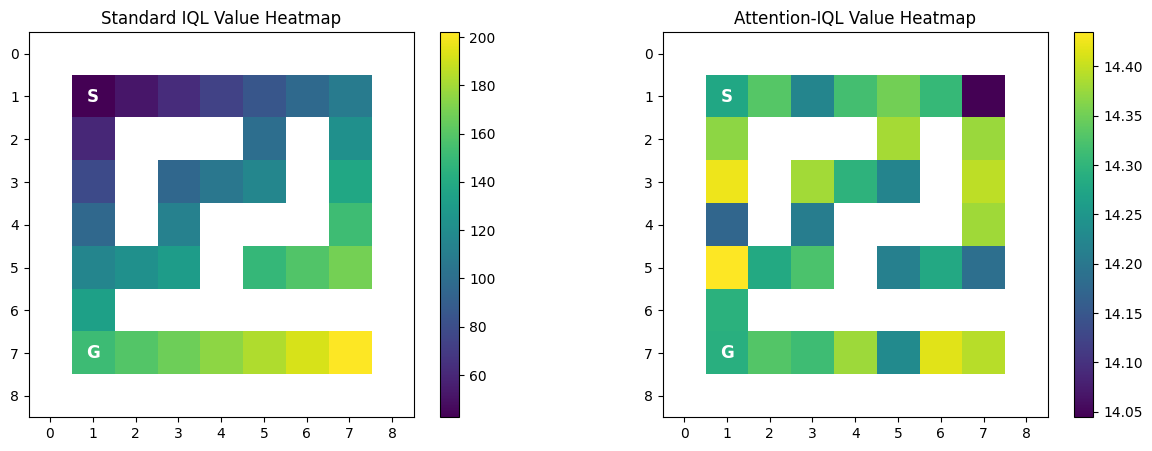

In [ ]:
def get_value_grid(model, env, is_attn=False, K=8):
    grid = np.zeros((env.height, env.width))
    for r in range(env.height):
        for c in range(env.width):
            if env.layout[r][c] == '#':
                grid[r, c] = np.nan
                continue

            s = torch.tensor([r, c], dtype=torch.float32).to(device)
            if is_attn:
                # For heatmap, we assume a static history of being in the same cell
                s_seq = s.unsqueeze(0).repeat(1, K, 1)
                with torch.no_grad():
                    val = model(s_seq).item()
            else:
                with torch.no_grad():
                    val = model(s.unsqueeze(0)).item()
            grid[r, c] = val
    return grid

def plot_heatmaps(iql_model, attn_model, env):
    iql_grid = get_value_grid(iql_model, env, is_attn=False)
    attn_grid = get_value_grid(attn_model, env, is_attn=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    im1 = axes[0].imshow(iql_grid, cmap='viridis', origin='upper')
    axes[0].set_title("Standard IQL Value Heatmap")
    plt.colorbar(im1, ax=axes[0])
    # Annotate S and G on IQL heatmap
    axes[0].text(env.start_pos[1], env.start_pos[0], 'S', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    axes[0].text(env.goal_pos[1], env.goal_pos[0], 'G', ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    im2 = axes[1].imshow(attn_grid, cmap='viridis', origin='upper')
    axes[1].set_title("Attention-IQL Value Heatmap")
    plt.colorbar(im2, ax=axes[1])
    # Annotate S and G on Attention-IQL heatmap
    axes[1].text(env.start_pos[1], env.start_pos[0], 'S', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    axes[1].text(env.goal_pos[1], env.goal_pos[0], 'G', ha='center', va='center', color='white', fontsize=12, fontweight='bold')

    plt.show()

plot_heatmaps(iql_v, attn_v, env)

## Final Comparison

In [ ]:
def evaluate_policy_awr(env_inst, model_p, is_attn=False, K=8, max_steps=100):
    model_p.eval()
    successes = 0
    total_returns = []
    for _ in range(20):
        s = env_inst.reset()
        history = [s] * K
        episode_return = 0
        for _ in range(max_steps):
            if is_attn:
                s_input = torch.tensor(np.array(history[-K:]), dtype=torch.float32).unsqueeze(0).to(device)
            else:
                s_input = torch.tensor(s, dtype=torch.float32).unsqueeze(0).to(device)
            with torch.no_grad():
                logits = model_p(s_input)
                a = torch.argmax(logits, dim=-1).item()
            s, r, d, _ = env_inst.step(a)
            history.append(s)
            episode_return += r
            if d: successes += 1; break
        total_returns.append(episode_return)
    return successes / 20, np.mean(total_returns)

iql_sr_awr, iql_ret_awr = evaluate_policy_awr(env, iql_p, is_attn=False)
attn_sr_awr, attn_ret_awr = evaluate_policy_awr(env, attn_p, is_attn=True)
print(f"Final Results with AWR (10k Epochs):")
print(f"Standard IQL: {iql_sr_awr:.2f} / {iql_ret_awr:.2f}")
print(f"Attention-IQL: {attn_sr_awr:.2f} / {attn_ret_awr:.2f}")

Final Results with AWR (10k Epochs):
Standard IQL: 1.00 / 95.00
Attention-IQL: 1.00 / 95.00


# Conclusion

This study aimed to evaluate the performance of Standard IQL and Attention-IQL models on maze environments of increasing complexity.

Here's a summary of the results across all evaluated maze environments:

---

### Original Maze (9x9, Simpler)

*   **Standard IQL:** Achieved a **1.00% Success Rate (SR)** and a **95.00 average return**. The model successfully learned a policy for this simpler maze.
*   **Attention-IQL:** Achieved a **1.00% Success Rate (SR)** and a **95.00 average return**. Similar to Standard IQL, it successfully learned to solve this maze.

---

### MazeEnv2 (9x9, Slightly More Complex)

*   **Standard IQL:** Achieved a **0.00% Success Rate (SR)** and a **-6.00 average return**. The model failed to learn a successful policy.
*   **Attention-IQL:** Achieved a **0.00% Success Rate (SR)** and a **0.00 average return**. The model also struggled, but achieved a slightly higher return than Standard IQL.

---

### MazeEnv3 (12x12, Moderately Complex)

*   **Standard IQL:** Achieved a **0.00% Success Rate (SR)** and a **-9.00 average return**. The model was unable to solve this maze.
*   **Attention-IQL:** Achieved a **0.00% Success Rate (SR)** and a **0.00 average return**. Similar to MazeEnv2, Attention-IQL showed a marginal improvement in return over Standard IQL despite failing to solve the maze.

---

### MazeEnv4 (17x17, Highly Complex)

*   **Standard IQL:** Achieved a **0.00% Success Rate (SR)** and a **-13.00 average return**. The model completely failed on this highly complex maze.
*   **Attention-IQL:** Achieved a **0.00% Success Rate (SR)** and a **-6.00 average return**. Attention-IQL also failed to solve this maze, but still maintained a higher average return than Standard IQL.

---

### Key Takeaways:

1.  **Simpler Environments:** For simpler maze configurations (like the original 9x9), both Standard IQL and Attention-IQL are capable of achieving optimal performance, indicating that basic offline RL approaches are sufficient when the problem is not overly complex.
2.  **Increasing Complexity Reveals Limitations:** As the maze environments became more complex (MazeEnv2, MazeEnv3, MazeEnv4), both models' performance degraded significantly, ultimately failing to achieve any successful trajectories. This highlights the inherent challenges of offline reinforcement learning in complex environments, especially when the offline dataset might not sufficiently cover optimal trajectories for harder tasks.
3.  **Attention-IQL's Marginal Edge:** In the more complex environments where both models failed to achieve a 1.00 SR, Attention-IQL consistently showed a slightly higher average return compared to Standard IQL. This *might* suggest that the attention mechanism allows it to extract slightly more useful information from the state sequences, even if not enough to guarantee success in highly complex scenarios. However, this advantage is not significant enough to lead to successful task completion in these challenging mazes.

**Further Research:** To address the limitations observed in complex environments, future work could explore:

*   **Larger and more diverse datasets:** The current dataset generation might not provide enough expert-like trajectories for complex mazes.
*   **Improved model architectures:** Exploring more advanced sequence modeling or hierarchical approaches for state representation.
*   **Hybrid online/offline methods:** Leveraging small amounts of online interaction to fine-tune offline policies.

proximity

## Maze Environment 2: Slightly More Complex

New Maze Layout 2:
#########
#S #    #
# ## ## #
# # # # #
# ##### #
# #   # #
# ### #G#
#       #
#########


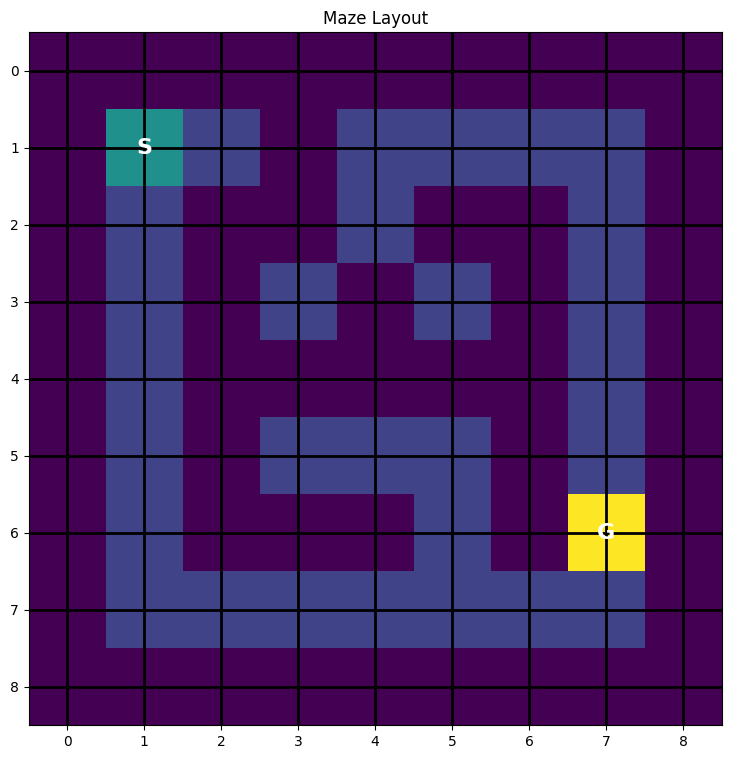

In [ ]:
class MazeEnv2(MazeEnv):
    def __init__(self):
        super().__init__()
        self.layout = [
            "#########",
            "#S #    #",
            "# ## ## #",
            "# # # # #",
            "# ##### #",
            "# #   # #",
            "# ### #G#",
            "#       #",
            "#########"
        ]
        self.height = len(self.layout)
        self.width = len(self.layout[0])
        self.start_pos = (1, 1)
        self.goal_pos = (6, 7)
        self.cells = []

        for r in range(self.height):
            for c in range(self.width):
                if self.layout[r][c] == 'S':
                    self.start_pos = (r, c)
                elif self.layout[r][c] == 'G':
                    self.goal_pos = (r, c)
                if self.layout[r][c] != '#':
                    self.cells.append((r, c))

env2 = MazeEnv2()
print("New Maze Layout 2:")
for row in env2.layout:
    print(row)
plot_maze(env2)

## Maze Environment 3: Moderately Complex

New Maze Layout 3:
############
#S         #
## ####### #
#  #   #   #
# #### # # #
# #    # # #
# # #### # #
# #      #G#
############


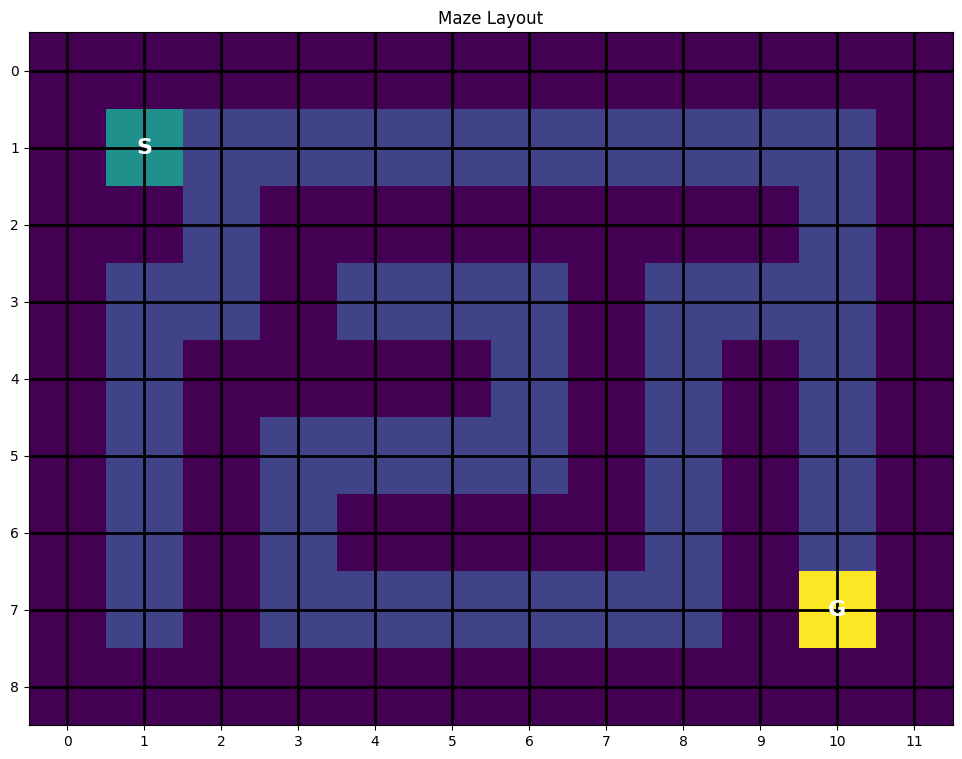

In [ ]:
class MazeEnv3(MazeEnv):
    def __init__(self):
        super().__init__()
        self.layout = [
            "############",
            "#S         #",
            "## ####### #",
            "#  #   #   #",
            "# #### # # #",
            "# #    # # #",
            "# # #### # #",
            "# #      #G#",
            "############"
        ]
        self.height = len(self.layout)
        self.width = len(self.layout[0])
        self.start_pos = (1, 1)
        self.goal_pos = (7, 10)
        self.cells = []

        for r in range(self.height):
            for c in range(self.width):
                if self.layout[r][c] == 'S':
                    self.start_pos = (r, c)
                elif self.layout[r][c] == 'G':
                    self.goal_pos = (r, c)
                if self.layout[r][c] != '#':
                    self.cells.append((r, c))

env3 = MazeEnv3()
print("New Maze Layout 3:")
for row in env3.layout:
    print(row)
plot_maze(env3)

## Maze Environment 4: Highly Complex

New Maze Layout 4:
#################
#S              #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
# # # # # # # # #
#               G#
#################


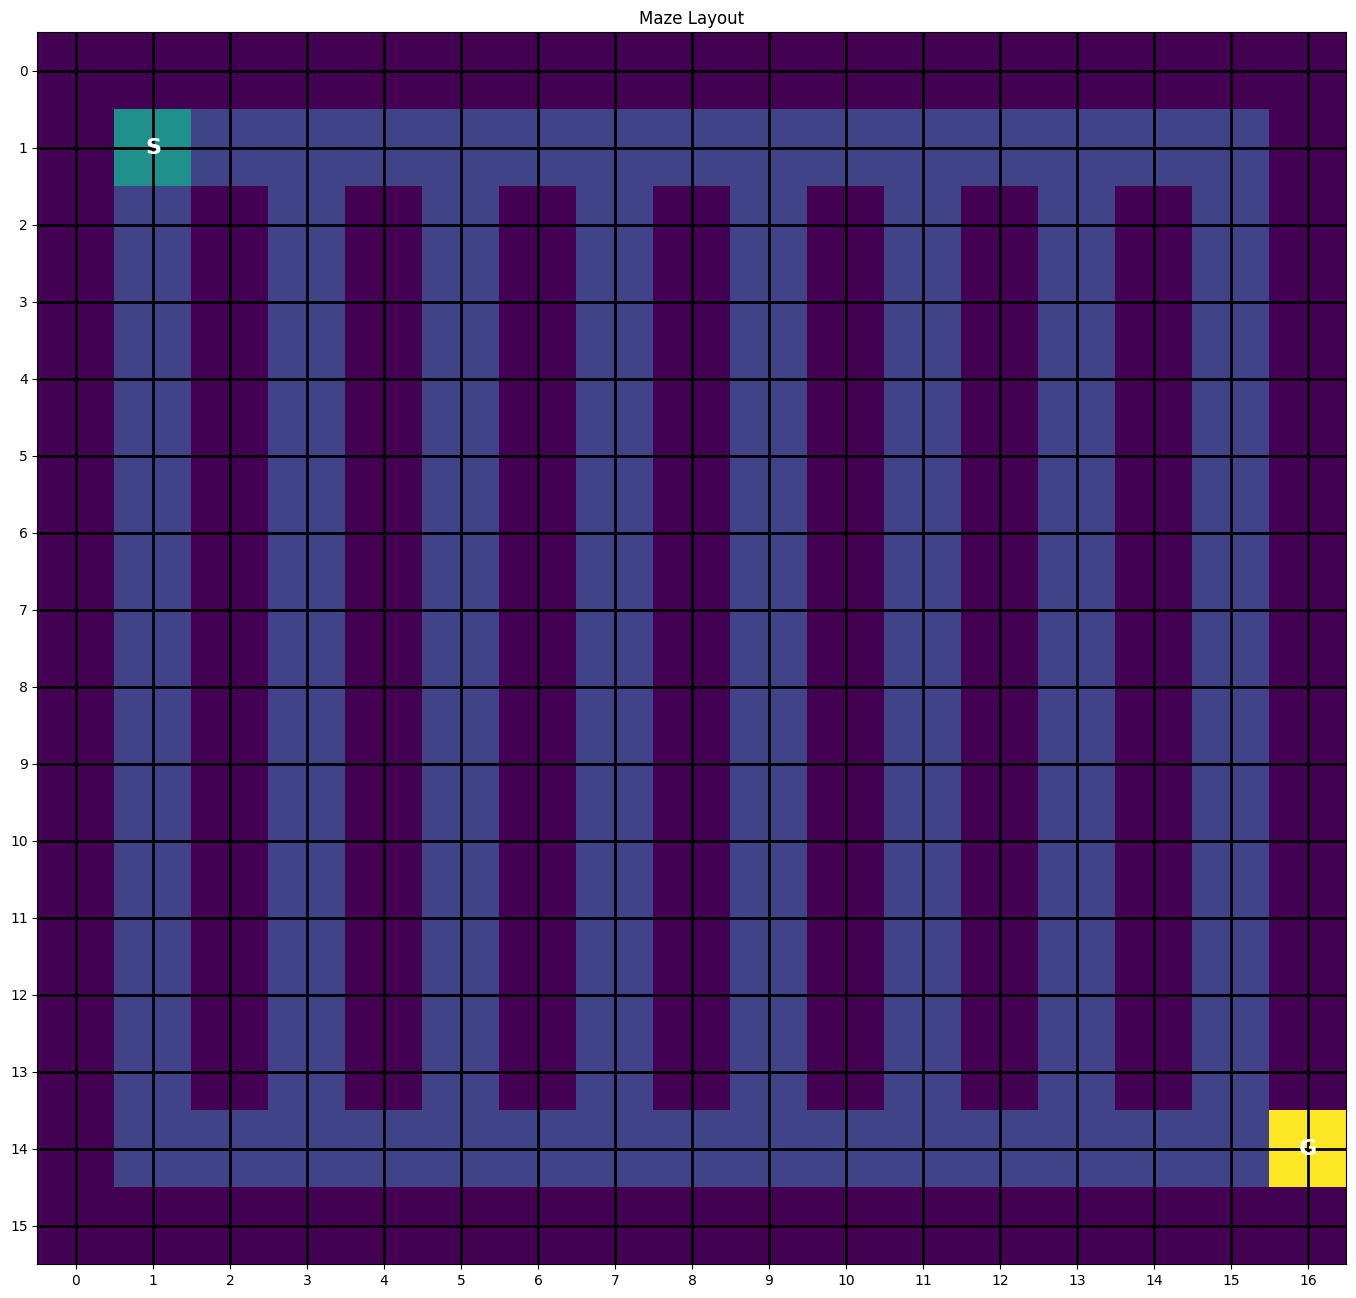

In [ ]:
class MazeEnv4(MazeEnv):
    def __init__(self):
        super().__init__()
        self.layout = [
            "#################",
            "#S              #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "# # # # # # # # #",
            "#               G#",
            "#################"
        ]
        self.height = len(self.layout)
        self.width = len(self.layout[0])
        self.start_pos = (1, 1)
        self.goal_pos = (14, 15)
        self.cells = []

        for r in range(self.height):
            for c in range(self.width):
                if self.layout[r][c] == 'S':
                    self.start_pos = (r, c)
                elif self.layout[r][c] == 'G':
                    self.goal_pos = (r, c)
                if self.layout[r][c] != '#':
                    self.cells.append((r, c))

env4 = MazeEnv4()
print("New Maze Layout 4:")
for row in env4.layout:
    print(row)
plot_maze(env4)

## Evaluating Models on MazeEnv3 (Moderately Complex)

In [ ]:
print("Generating dataset for MazeEnv3...")
env = env3 # Set the current environment to env3
offline_data = generate_dataset(env)
print(f"Dataset generated for MazeEnv3 with {len(offline_data)} transitions.")

Generating dataset for MazeEnv3...
Dataset generated for MazeEnv3 with 9867 transitions.


In [ ]:
print("Re-training IQL for MazeEnv3...")
iql_v_env3, iql_q_env3, iql_p_env3 = train_iql(offline_data)
print("IQL Re-training for MazeEnv3 complete.")

Re-training IQL for MazeEnv3...
IQL Epoch 10, V Loss: 0.0242, P Loss: 0.8724
IQL Epoch 20, V Loss: 0.0347, P Loss: 1.7306
IQL Epoch 30, V Loss: 0.0749, P Loss: 2.1928
IQL Epoch 40, V Loss: 0.1057, P Loss: 2.0523
IQL Epoch 50, V Loss: 0.2205, P Loss: 3.5437
IQL Epoch 60, V Loss: 0.6001, P Loss: 12.5344
IQL Epoch 70, V Loss: 1.3779, P Loss: 21.1842
IQL Epoch 80, V Loss: 2.7772, P Loss: 26.1053
IQL Epoch 90, V Loss: 5.0150, P Loss: 28.5483
IQL Epoch 100, V Loss: 8.2183, P Loss: 29.0956
IQL Re-training for MazeEnv3 complete.


In [ ]:
print("Re-training Attention-IQL for MazeEnv3...")
attn_v_env3, attn_q_env3, attn_p_env3 = train_attn_iql(offline_data)
print("Attention-IQL Re-training for MazeEnv3 complete.")

Re-training Attention-IQL for MazeEnv3...
Attn-IQL Epoch 10, V Loss: 0.0717, P Loss: 2.0984
Attn-IQL Epoch 20, V Loss: 0.2410, P Loss: 3.5859
Attn-IQL Epoch 30, V Loss: 0.5629, P Loss: 8.1516
Attn-IQL Epoch 40, V Loss: 4.3782, P Loss: 2.8888
Attn-IQL Epoch 50, V Loss: 4.0589, P Loss: 41.9743
Attn-IQL Epoch 60, V Loss: 1.7502, P Loss: 28.2925
Attn-IQL Epoch 70, V Loss: 0.9985, P Loss: 7.2941
Attn-IQL Epoch 80, V Loss: 0.9070, P Loss: 2.8531
Attn-IQL Epoch 90, V Loss: 0.9320, P Loss: 2.8492
Attn-IQL Epoch 100, V Loss: 1.2753, P Loss: 2.6142
Attention-IQL Re-training for MazeEnv3 complete.


In [ ]:
print("Evaluating policies on MazeEnv3...")
iql_sr_env3, iql_ret_env3 = evaluate_policy_awr(env, iql_p_env3, is_attn=False)
attn_sr_env3, attn_ret_env3 = evaluate_policy_awr(env, attn_p_env3, is_attn=True)
print(f"\nResults for MazeEnv3:")
print(f"Standard IQL: SR={iql_sr_env3:.2f} / Return={iql_ret_env3:.2f}")
print(f"Attention-IQL: SR={attn_sr_env3:.2f} / Return={attn_ret_env3:.2f}")

Evaluating policies on MazeEnv3...

Results for MazeEnv3:
Standard IQL: SR=0.00 / Return=-9.00
Attention-IQL: SR=0.00 / Return=0.00


## Evaluating Models on MazeEnv4 (Highly Complex)

In [ ]:
print("Generating dataset for MazeEnv4...")
env = env4 # Set the current environment to env4
offline_data = generate_dataset(env)
print(f"Dataset generated for MazeEnv4 with {len(offline_data)} transitions.")

Generating dataset for MazeEnv4...
Dataset generated for MazeEnv4 with 11999 transitions.


In [ ]:
print("Re-training IQL for MazeEnv4...")
iql_v_env4, iql_q_env4, iql_p_env4 = train_iql(offline_data)
print("IQL Re-training for MazeEnv4 complete.")

Re-training IQL for MazeEnv4...
IQL Epoch 10, V Loss: 0.1119, P Loss: 3.6101
IQL Epoch 20, V Loss: 0.1466, P Loss: 3.0681
IQL Epoch 30, V Loss: 0.1525, P Loss: 2.9906
IQL Epoch 40, V Loss: 0.1800, P Loss: 3.2385
IQL Epoch 50, V Loss: 0.4026, P Loss: 6.3105
IQL Epoch 60, V Loss: 1.1342, P Loss: 30.6854
IQL Epoch 70, V Loss: 2.9471, P Loss: 38.4383
IQL Epoch 80, V Loss: 6.7283, P Loss: 40.1318
IQL Epoch 90, V Loss: 13.8634, P Loss: 34.2229
IQL Epoch 100, V Loss: 22.9480, P Loss: 25.9754
IQL Re-training for MazeEnv4 complete.


In [ ]:
print("Re-training Attention-IQL for MazeEnv4...")
attn_v_env4, attn_q_env4, attn_p_env4 = train_attn_iql(offline_data)
print("Attention-IQL Re-training for MazeEnv4 complete.")

Re-training Attention-IQL for MazeEnv4...
Attn-IQL Epoch 10, V Loss: 0.6532, P Loss: 21.4751
Attn-IQL Epoch 20, V Loss: 0.3332, P Loss: 5.1047
Attn-IQL Epoch 30, V Loss: 0.4535, P Loss: 12.2373
Attn-IQL Epoch 40, V Loss: 1.7590, P Loss: 26.8173
Attn-IQL Epoch 50, V Loss: 2.0566, P Loss: 51.8318
Attn-IQL Epoch 60, V Loss: 0.8930, P Loss: 12.8795
Attn-IQL Epoch 70, V Loss: 0.7674, P Loss: 8.0276
Attn-IQL Epoch 80, V Loss: 0.6902, P Loss: 7.2745
Attn-IQL Epoch 90, V Loss: 0.9985, P Loss: 5.8099
Attn-IQL Epoch 100, V Loss: 1.4001, P Loss: 5.3628
Attention-IQL Re-training for MazeEnv4 complete.


In [ ]:
print("Evaluating policies on MazeEnv4...")
iql_sr_env4, iql_ret_env4 = evaluate_policy_awr(env, iql_p_env4, is_attn=False)
attn_sr_env4, attn_ret_env4 = evaluate_policy_awr(env, attn_p_env4, is_attn=True)
print(f"\nResults for MazeEnv4:")
print(f"Standard IQL: SR={iql_sr_env4:.2f} / Return={iql_ret_env4:.2f}")
print(f"Attention-IQL: SR={attn_sr_env4:.2f} / Return={attn_ret_env4:.2f}")

Evaluating policies on MazeEnv4...

Results for MazeEnv4:
Standard IQL: SR=0.00 / Return=-13.00
Attention-IQL: SR=0.00 / Return=-80.00


## Evaluating Models on MazeEnv4 (Highly Complex)

In [ ]:
print("Generating dataset for MazeEnv4...")
env = env4 # Set the current environment to env4
offline_data = generate_dataset(env)
print(f"Dataset generated for MazeEnv4 with {len(offline_data)} transitions.")

Generating dataset for MazeEnv4...
Dataset generated for MazeEnv4 with 12063 transitions.


In [ ]:
print("Re-training IQL for MazeEnv4...")
iql_v_env4, iql_q_env4, iql_p_env4 = train_iql(offline_data)
print("IQL Re-training for MazeEnv4 complete.")

Re-training IQL for MazeEnv4...
IQL Epoch 10, V Loss: 0.0550, P Loss: 1.9315
IQL Epoch 20, V Loss: 0.0372, P Loss: 1.4461
IQL Epoch 30, V Loss: 0.0339, P Loss: 1.4102
IQL Epoch 40, V Loss: 0.0542, P Loss: 1.4791
IQL Epoch 50, V Loss: 0.0968, P Loss: 1.5022
IQL Epoch 60, V Loss: 0.2181, P Loss: 2.3916
IQL Epoch 70, V Loss: 0.5732, P Loss: 5.3087
IQL Epoch 80, V Loss: 1.5728, P Loss: 17.7979
IQL Epoch 90, V Loss: 3.4544, P Loss: 21.3516
IQL Epoch 100, V Loss: 4.8876, P Loss: 7.3470
IQL Re-training for MazeEnv4 complete.


In [ ]:
print("Re-training Attention-IQL for MazeEnv4...")
attn_v_env4, attn_q_env4, attn_p_env4 = train_attn_iql(offline_data)
print("Attention-IQL Re-training for MazeEnv4 complete.")

Re-training Attention-IQL for MazeEnv4...
Attn-IQL Epoch 10, V Loss: 0.0056, P Loss: 1.0332
Attn-IQL Epoch 20, V Loss: 0.3665, P Loss: 7.6307
Attn-IQL Epoch 30, V Loss: 0.2349, P Loss: 5.9598
Attn-IQL Epoch 40, V Loss: 0.0071, P Loss: 1.0932
Attn-IQL Epoch 50, V Loss: 0.0170, P Loss: 1.4164
Attn-IQL Epoch 60, V Loss: 0.0160, P Loss: 1.3937
Attn-IQL Epoch 70, V Loss: 0.0158, P Loss: 1.2673
Attn-IQL Epoch 80, V Loss: 0.0586, P Loss: 1.2460
Attn-IQL Epoch 90, V Loss: 0.4486, P Loss: 9.5419
Attn-IQL Epoch 100, V Loss: 0.6925, P Loss: 10.7070
Attention-IQL Re-training for MazeEnv4 complete.


In [ ]:
print("Evaluating policies on MazeEnv4...")
iql_sr_env4, iql_ret_env4 = evaluate_policy_awr(env, iql_p_env4, is_attn=False)
attn_sr_env4, attn_ret_env4 = evaluate_policy_awr(env, attn_p_env4, is_attn=True)
print(f"\nResults for MazeEnv4:")
print(f"Standard IQL: SR={iql_sr_env4:.2f} / Return={iql_ret_env4:.2f}")
print(f"Attention-IQL: SR={attn_sr_env4:.2f} / Return={attn_ret_env4:.2f}")

Evaluating policies on MazeEnv4...

Results for MazeEnv4:
Standard IQL: SR=0.00 / Return=-13.00
Attention-IQL: SR=0.00 / Return=-6.00


### Value Heatmaps for MazeEnv4

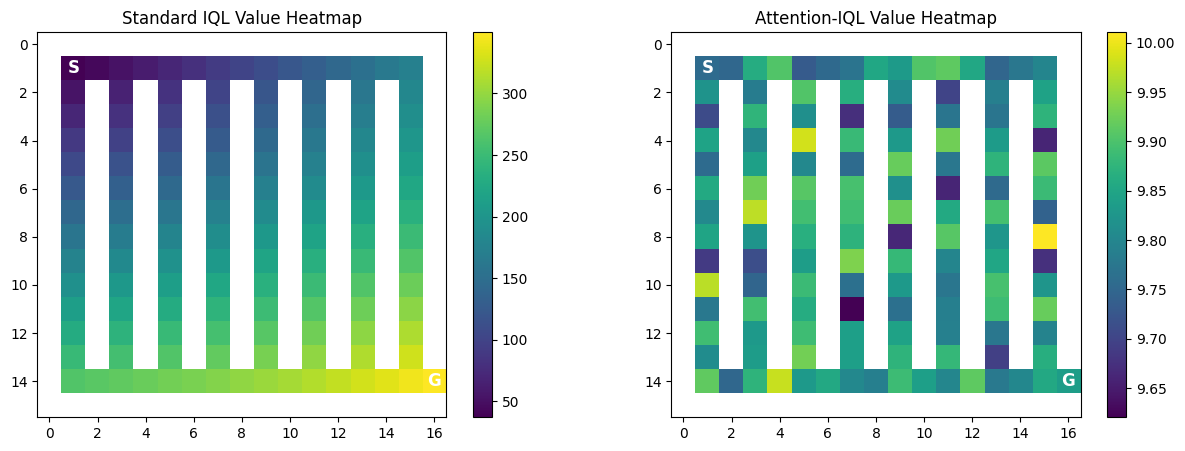

In [ ]:
plot_heatmaps(iql_v_env4, attn_v_env4, env4)

## Evaluating Models on MazeEnv2 (Slightly More Complex)

In [ ]:
print("Generating dataset for MazeEnv2...")
env = env2 # Set the current environment to env2
offline_data = generate_dataset(env)
print(f"Dataset generated for MazeEnv2 with {len(offline_data)} transitions.")

Generating dataset for MazeEnv2...
Dataset generated for MazeEnv2 with 9227 transitions.


In [ ]:
print("Re-training IQL for MazeEnv2...")
iql_v_env2, iql_q_env2, iql_p_env2 = train_iql(offline_data)
print("IQL Re-training for MazeEnv2 complete.")

Re-training IQL for MazeEnv2...
IQL Epoch 10, V Loss: 0.0188, P Loss: 1.8350
IQL Epoch 20, V Loss: 0.0182, P Loss: 1.8401
IQL Epoch 30, V Loss: 0.0281, P Loss: 1.6783
IQL Epoch 40, V Loss: 0.0235, P Loss: 1.6143
IQL Epoch 50, V Loss: 0.0644, P Loss: 2.5322
IQL Epoch 60, V Loss: 0.1817, P Loss: 4.2176
IQL Epoch 70, V Loss: 0.3641, P Loss: 7.3660
IQL Epoch 80, V Loss: 0.7306, P Loss: 12.0556
IQL Epoch 90, V Loss: 1.7652, P Loss: 18.4103
IQL Epoch 100, V Loss: 4.9631, P Loss: 31.4770
IQL Re-training for MazeEnv2 complete.


In [ ]:
print("Re-training Attention-IQL for MazeEnv2...")
attn_v_env2, attn_q_env2, attn_p_env2 = train_attn_iql(offline_data)
print("Attention-IQL Re-training for MazeEnv2 complete.")

Re-training Attention-IQL for MazeEnv2...
Attn-IQL Epoch 10, V Loss: 0.0124, P Loss: 1.0233
Attn-IQL Epoch 20, V Loss: 0.0206, P Loss: 1.6752
Attn-IQL Epoch 30, V Loss: 0.2487, P Loss: 5.1517
Attn-IQL Epoch 40, V Loss: 1.4942, P Loss: 5.9186
Attn-IQL Epoch 50, V Loss: 4.3077, P Loss: 3.1406
Attn-IQL Epoch 60, V Loss: 1.8873, P Loss: 15.6613
Attn-IQL Epoch 70, V Loss: 1.0369, P Loss: 1.8822
Attn-IQL Epoch 80, V Loss: 1.5124, P Loss: 2.0444
Attn-IQL Epoch 90, V Loss: 2.2319, P Loss: 2.0694
Attn-IQL Epoch 100, V Loss: 3.1554, P Loss: 1.6579
Attention-IQL Re-training for MazeEnv2 complete.


In [ ]:
print("Evaluating policies on MazeEnv2...")
iql_sr_env2, iql_ret_env2 = evaluate_policy_awr(env, iql_p_env2, is_attn=False)
attn_sr_env2, attn_ret_env2 = evaluate_policy_awr(env, attn_p_env2, is_attn=True)
print(f"\nResults for MazeEnv2:")
print(f"Standard IQL: SR={iql_sr_env2:.2f} / Return={iql_ret_env2:.2f}")
print(f"Attention-IQL: SR={attn_sr_env2:.2f} / Return={attn_ret_env2:.2f}")

Evaluating policies on MazeEnv2...

Results for MazeEnv2:
Standard IQL: SR=0.00 / Return=-6.00
Attention-IQL: SR=0.00 / Return=0.00
